# Usage of PySpark SQL

In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [ ]:
spark

In [ ]:
sc = spark.sparkContext

In [ ]:
## documentation
spark.read

In [ ]:
file_path = r'/content/npr.txt'

In [ ]:
article = spark.read.text(file_path)

In [ ]:
article.show()

+--------------------+
|               value|
+--------------------+
|When Ty Malugani ...|
|This was finally ...|
|                    |
|  Related Story: NPR|
|                    |
|"We always talked...|
|Soon enough, that...|
|                    |
|Fans aren't happy...|
|                    |
|Then there was th...|
|The last straw fo...|
|For Malugani, it ...|
|                    |
|  Related Story: NPR|
|                    |
|"It felt very muc...|
|With less than tw...|
|FIFA, for its par...|
|But there are sig...|
+--------------------+
only showing top 20 rows


In [ ]:
article.printSchema()

root
 |-- value: string (nullable = true)



In [ ]:
article.select(article.value)

DataFrame[value: string]

In [ ]:
article.show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                              |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|When Ty Malugani in Alabama heard the World Cup was coming to North America, he was thrilled.                                                                                                                      |
|This was finally his chance to go to a World Cup right in the U.S and take his four little ones to experience the game he loves. The U.S. is co

In [ ]:
from pyspark.sql.functions import col

In [ ]:

article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [ ]:
from pyspark.sql.functions import col, split

lines = article.select(
    split(col('value'), " ").alias('line')
)

In [ ]:
lines.printSchema()

root
 |-- line: array (nullable = true)
 |    |-- element: string (containsNull = false)



In [ ]:
lines.show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|line                                                                                                                                                                                                                                                        |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[When, Ty, Malugani, in, Alabama, heard, the, World, Cup, was, coming, to, North, America,, he, was, thrilled.]                                                                                                                           

In [ ]:
lines

DataFrame[line: array<string>]

In [ ]:
from pyspark.sql.functions import explode

words = lines.select(explode(col("line")).alias('word'))

In [ ]:
words.printSchema()

root
 |-- word: string (nullable = false)



In [ ]:
from pyspark.sql.functions import lower

words_lower = words.select(lower(col("word")).alias('word_lower'))

In [ ]:
words_lower.show(10)

+----------+
|word_lower|
+----------+
|      when|
|        ty|
|  malugani|
|        in|
|   alabama|
|     heard|
|       the|
|     world|
|       cup|
|       was|
+----------+
only showing top 10 rows


In [ ]:
words_lower['word_lower']

Column<'word_lower'>

In [ ]:
from pyspark.sql.functions import regexp_extract

words_clean = words_lower.select(
    regexp_extract(col("word_lower"), r"(\W+)?([a-z]+)", 2).alias("word_clean")
)

In [ ]:
words_clean.show(10)

+----------+
|word_clean|
+----------+
|      when|
|        ty|
|  malugani|
|        in|
|   alabama|
|     heard|
|       the|
|     world|
|       cup|
|       was|
+----------+
only showing top 10 rows


In [ ]:
words_nonull = words_clean.where(col("word_clean") != "")

words_nonull.show(100)

+--------------+
|    word_clean|
+--------------+
|          when|
|            ty|
|      malugani|
|            in|
|       alabama|
|         heard|
|           the|
|         world|
|           cup|
|           was|
|        coming|
|            to|
|         north|
|       america|
|            he|
|           was|
|      thrilled|
|          this|
|           was|
|       finally|
|           his|
|        chance|
|            to|
|            go|
|            to|
|             a|
|         world|
|           cup|
|         right|
|            in|
|           the|
|             u|
|           and|
|          take|
|           his|
|          four|
|        little|
|          ones|
|            to|
|    experience|
|           the|
|          game|
|            he|
|         loves|
|           the|
|             u|
|            is|
|            co|
|           the|
|    tournament|
|          with|
|        mexico|
|           and|
|        canada|
|      starting|
|            i

In [ ]:
groups = words_nonull.groupBy(col("word_clean"))

In [58]:
from pyspark.sql.functions import length

words_gt_three = words_nonull.filter(length(col("word_clean")) > 3)

In [60]:
words_gt_three.show(10)

+----------+
|word_clean|
+----------+
|      when|
|  malugani|
|   alabama|
|     heard|
|     world|
|    coming|
|     north|
|   america|
|  thrilled|
|      this|
+----------+
only showing top 10 rows


In [61]:
groups = words_gt_three.groupBy(col("word_clean"))

In [72]:
counts = groups.count()

In [74]:
counts.orderBy('count', ascending=False).show(10)

+----------+-----+
|word_clean|count|
+----------+-----+
|     world|   15|
|      that|   14|
|      says|   12|
|      fifa|   10|
|      from|    8|
|tournament|    7|
|  malugani|    6|
|      also|    6|
|      like|    6|
|      seen|    5|
+----------+-----+
only showing top 10 rows


In [73]:
import pandas as pd

pdf = counts.toPandas()



In [69]:
pdf

,word_clean,count
0,those,5
1,some,5
2,still,2
3,travel,1
4,involving,1
...,...,...
354,almost,1
355,which,4
356,killed,1
357,related,4


In [76]:
long_string = ''.join(pdf['word_clean'].astype(str))

In [77]:
long_string

'thosesomestilltravelinvolvingincludetakingwatchportugalcountriesdozengrowsubjectdraconiansafestalabamawhethermaluganiindustryseatingnosebleedalwaysperfectpricestryingdemandbookingscouldgreatestincrediblestartingstrawfinancehopefullycheapestairfaresseensellingestateroomsdaviswillrosannabecauseamericalodgingusingsuccesseverythinghotelsopeningexpectationsvarietypopulartrumpmorewelcomefrustratedvisitorsbackopportunitythereattendallowlovingstatementtiminghotelbiggestpusheddisappointmentbringturnedmeantcanceledbelowproviderlovesoonrecentfourtickethopescostarbansadministrationimpactactuallytheyhostsimmigrationpersonaccordingmajorbecomewithconfusingtoldprofessorgivengroupamericancountitselfdirectorattendingunitedadamanttakequiteresoundingfuturehimselfreportingdoubtstoryagreementscitieshappenedsupereventsthanleftanalyzespoliciesfocusedpodcastteamreasonlongerronaldohopefulthrilledcancellationssuchensuringsportfamilyfeltsignsconfluencehoweverotherhavingwhenwhitenegativeenoughhospitalitykieranmis

In [78]:
counts = {}

for char in long_string.lower():
    counts[char] = counts.get(char, 0) + 1



In [89]:
counts_df = pd.DataFrame.from_dict(counts, orient='index')

count_df = counts_df.sort_index()
count_df

,0
a,190
b,25
c,91
d,74
e,282
f,35
g,75
h,71
i,170
j,4


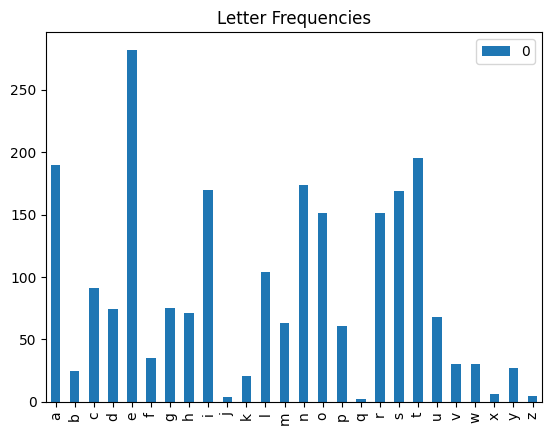

In [90]:
import matplotlib.pyplot as plt

count_df.plot(kind='bar', title='Letter Frequencies', )
plt.show()

In [ ]:
import pyspark.sql.functions as F

counts = (
    spark.read.text(file_path)
     .select(F.split(F.col('value'), ' ').alias('line'))
     .select(F.explode(F.col('line')).alias('word'))
     .select(F.lower(F.col('word')).alias('word'))
     .select(F.regexp_extract(F.col('word'), r"(\W+)?([a-z]+)", 2).alias('word'))
     .where(F.col('word') != "")
     .groupby('word')
     .count()
)

In [ ]:
counts.show(10)